In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import jax.numpy as jnp
from jax import grad, vmap
from matplotlib.colors import LogNorm
import jax
import random

from JAX_Deprojection import surface_brightness as sb
from JAX_Deprojection import density_distribution as den
import jax
import numpyro
import numpyro.distributions as dist
from tinygp import kernels, GaussianProcess
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer import SVI, Trace_ELBO
from numpyro.optim import Adam
from jax.scipy.interpolate import RegularGridInterpolator

In [26]:
s_def = 1. 

e_k_def = 0.0 
e_d_def = 0.0

p_a_def = 0.00160907
p_b_def = -0.02122767
p_c_def = 0.07711992
p_d_def = 0.54249868

q_a_def = 0.0
q_b_def = 0.0
q_c_def = 0.0
q_d_def = 0.6

a_def = 2.
b_def = 4.
rho0_def = 0.001
i_def = 0.
phi_def = 0.
theta_def = 0.

size = 100
extent = 5
extents = [-extent, extent,-extent, extent]

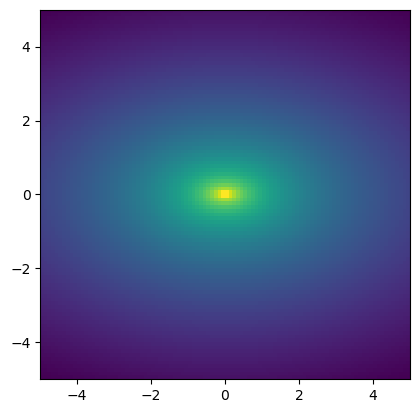

In [27]:
sb_1= sb.Surface_brightness()
sb_1.generate(size,extent, e_k_def, e_d_def, p_a_def, p_b_def, p_c_def, p_d_def, q_a_def, q_b_def, q_c_def, q_d_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
img1 = plt.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)

In [28]:
sb_1.data.size

10000

In [29]:
def rho(x, y, z, e, p, q, rho0, s, a, b):
    #eps = 1e-12
    #r = (jnp.abs(x)**2 + jnp.abs(y)**2 + jnp.abs(z)**2)**0.5
    m = ((jnp.abs(x)**(2 - e) + (jnp.abs(y) / p)**(2 - e) + (jnp.abs(z) / q)**(2 - e)))**(1 / (2 - e)) 
    #m = jnp.maximum(m, eps)
    den = rho0 / ((m / s)**a * (1 + (m / s))**(b - a))
    return den / (p * q)

In [30]:
def model(x, y, z, rho_obs=None):
    #eps = 1e-12
    r = jnp.sqrt(x**2 + y**2 + z**2)
    #r = jnp.maximum(r,eps)
    
    # GP parameters for p(r)
    sigma_p = numpyro.param("sigma_p", jnp.ones(()), constraint=dist.constraints.positive)
    length_scale_p = numpyro.param("length_scale_p", jnp.array(0.5), constraint=dist.constraints.positive)
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r, diag=1e-5, mean=1.0)  
    p_sampled = numpyro.sample("p", gp_p.numpyro_dist())
    p_sampled = jax.nn.sigmoid(p)

    #interpolator = RegularGridInterpolator((r,), p_sampled, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    #p_sampled = interpolator(r)

    # Constant parameters
    q = 0.8
    e = 0.0
    rho0 = 1.0
    s = 1.0
    a = 1.0
    b = 2.0

    # Compute the density
    density = rho(x, y, z, e, p_sampled, q, rho0, s, a, b)

    # Observation model
    numpyro.sample("rho_obs", dist.Normal(density, 0.1), obs=rho_obs)